# FLOOD PREDICTION


This regression project focuses on analyzing factors that influence flood risk and predicting flood levels based on various environmental and human-related variables. Examinine attributes such as monsoon intensity, urbanization, and land management practices. Understanding these relationships is crucial for developing effective flood management strategies. Ultimately, this project seeks to enhance preparedness and response measures for flood events.


## DATA SET

* MonsoonIntensity: Refers to the strength and duration of monsoon rains, significantly influencing flood levels.
* TopographyDrainage: Involves the landscape features and drainage patterns that affect how water flows and accumulates during heavy rainfall.
* RiverManagement: Encompasses strategies and practices for controlling river flow and maintaining water levels to mitigate flooding.
* Deforestation: The removal of trees and vegetation that can lead to increased runoff and reduced water absorption, heightening flood risk.
* Urbanization: The expansion of urban areas, which often results in impervious surfaces that prevent water from soaking into the ground, increasing flood potential.
* ClimateChange: Refers to long-term changes in climate patterns that can lead to more severe and frequent flooding events.
* DamsQuality: The structural integrity and management of dams, which are critical for controlling water flow and preventing floods.
* Siltation: The accumulation of sediments in rivers and reservoirs, which can reduce water capacity and increase flood risk.
* AgriculturalPractices: Farming methods that influence soil health and water retention, impacting the likelihood of flooding in surrounding areas.
* Encroachments: Unauthorized constructions in flood-prone areas that can obstruct water flow and exacerbate flooding.
* IneffectiveDisasterPreparedness: Lack of planning and resources to respond to flooding, leading to greater vulnerability during flood events.
* DrainageSystems: The infrastructure designed to manage excess water; inadequate systems can lead to flooding during heavy rains.
* CoastalVulnerability: The susceptibility of coastal areas to flooding from storm surges and rising sea levels.
* Landslides: The movement of rock or soil down a slope, often triggered by heavy rain, which can block waterways and create flooding.
* Watersheds: Regions that drain into a common water body; their health and management are crucial for controlling flood risks.
* DeterioratingInfrastructure: The decline of essential structures (like roads and bridges) that can impede water flow and exacerbate flooding.
* PopulationScore: A measure of population density and distribution in flood-prone areas, influencing overall risk and vulnerability.
* WetlandLoss: The degradation or destruction of wetlands, which serve as natural buffers against flooding by absorbing excess water.
* InadequatePlanning: Poor urban and regional planning that fails to consider flood risks, leading to increased vulnerability.
* PoliticalFactors: The influence of governance and policy decisions on flood management and disaster preparedness.
* FloodProbability: The likelihood of flooding occurring in a given area, influenced by various environmental and human factors.


# IMPORTS

####  Import Libraries and Load Data
We start by importing all necessary Python libraries for data handling, visualization, and machine learning.  
- `pandas` and `numpy` help us work with tabular data and arrays.
- `matplotlib` and `seaborn` are used for plotting graphs.
- `scikit-learn` provides tools for building and evaluating machine learning models.

We then load the flood dataset into a pandas DataFrame for analysis.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

import pickle

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import scale

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

# READING DATA
Training dataset:
https://www.kaggle.com/competitions/playground-series-s4e5/data?select=train.csv

In [ ]:
#uploading the dataset from the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#downloaded the dataset to google drive and loaded directly from google drive
df=pd.read_csv('drive/MyDrive/ML/train.csv')

# EDA
####  Initial Data Exploration
We check the shape, column types, and a sample of the data to:
- Understand the number of samples and features.
- Check for missing values or data issues.
- Get a first look at what the data looks like.
This helps us plan our next steps and spot any obvious problems.


In [ ]:
df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,4,2,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,6,9,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,5,6,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,8,5,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,3,5,2,2,6,6,4,1,2,3,5,0.415


In [ ]:
df.shape

(1117957, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [ ]:
null_values = df.isnull().sum()
null_values[null_values>0]

,0


# DATA VISUALIZATION

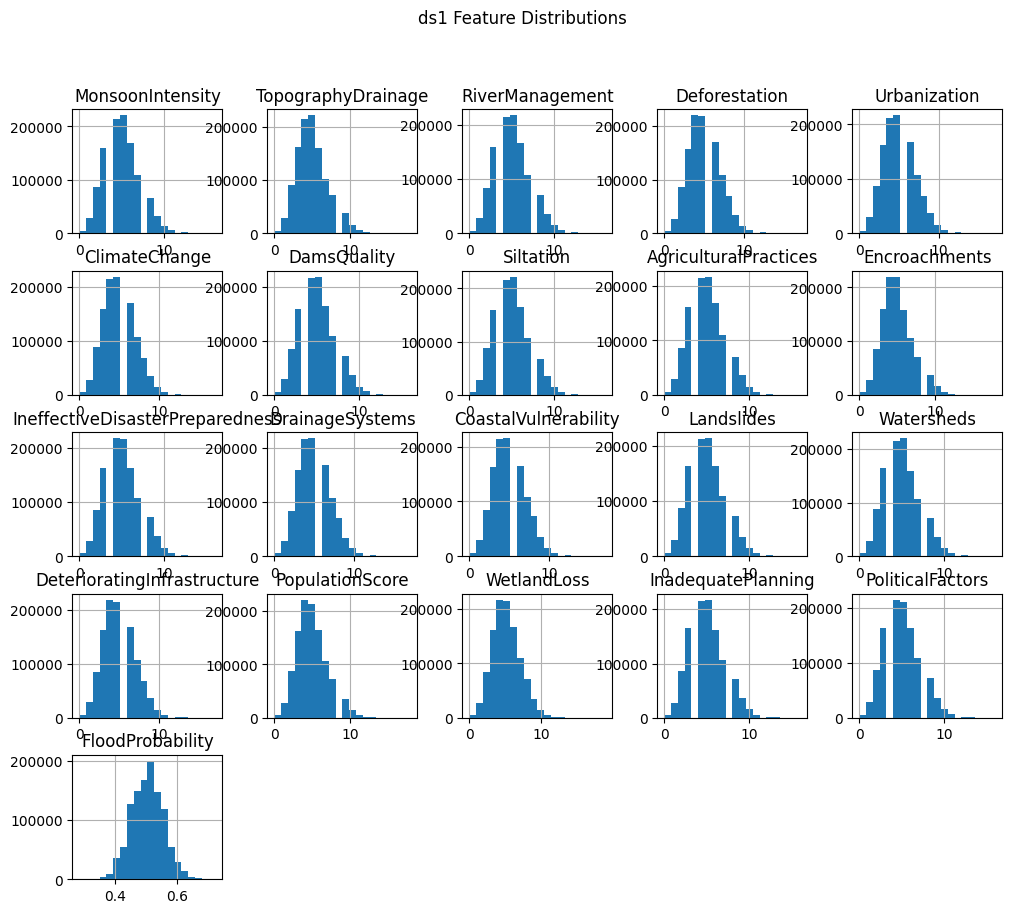

In [ ]:
import matplotlib.pyplot as plt
df.drop(columns='id').hist(figsize=(12,10), bins=20)
plt.suptitle('ds1 Feature Distributions')
plt.show()

####  Correlation Analysis
We use a heatmap to visualize correlations between all features and the target.
- This helps us check if any features are highly correlated (multicollinearity).
- High correlations can affect some models or suggest redundancy.
- We also look for any strong relationships with the target variable.


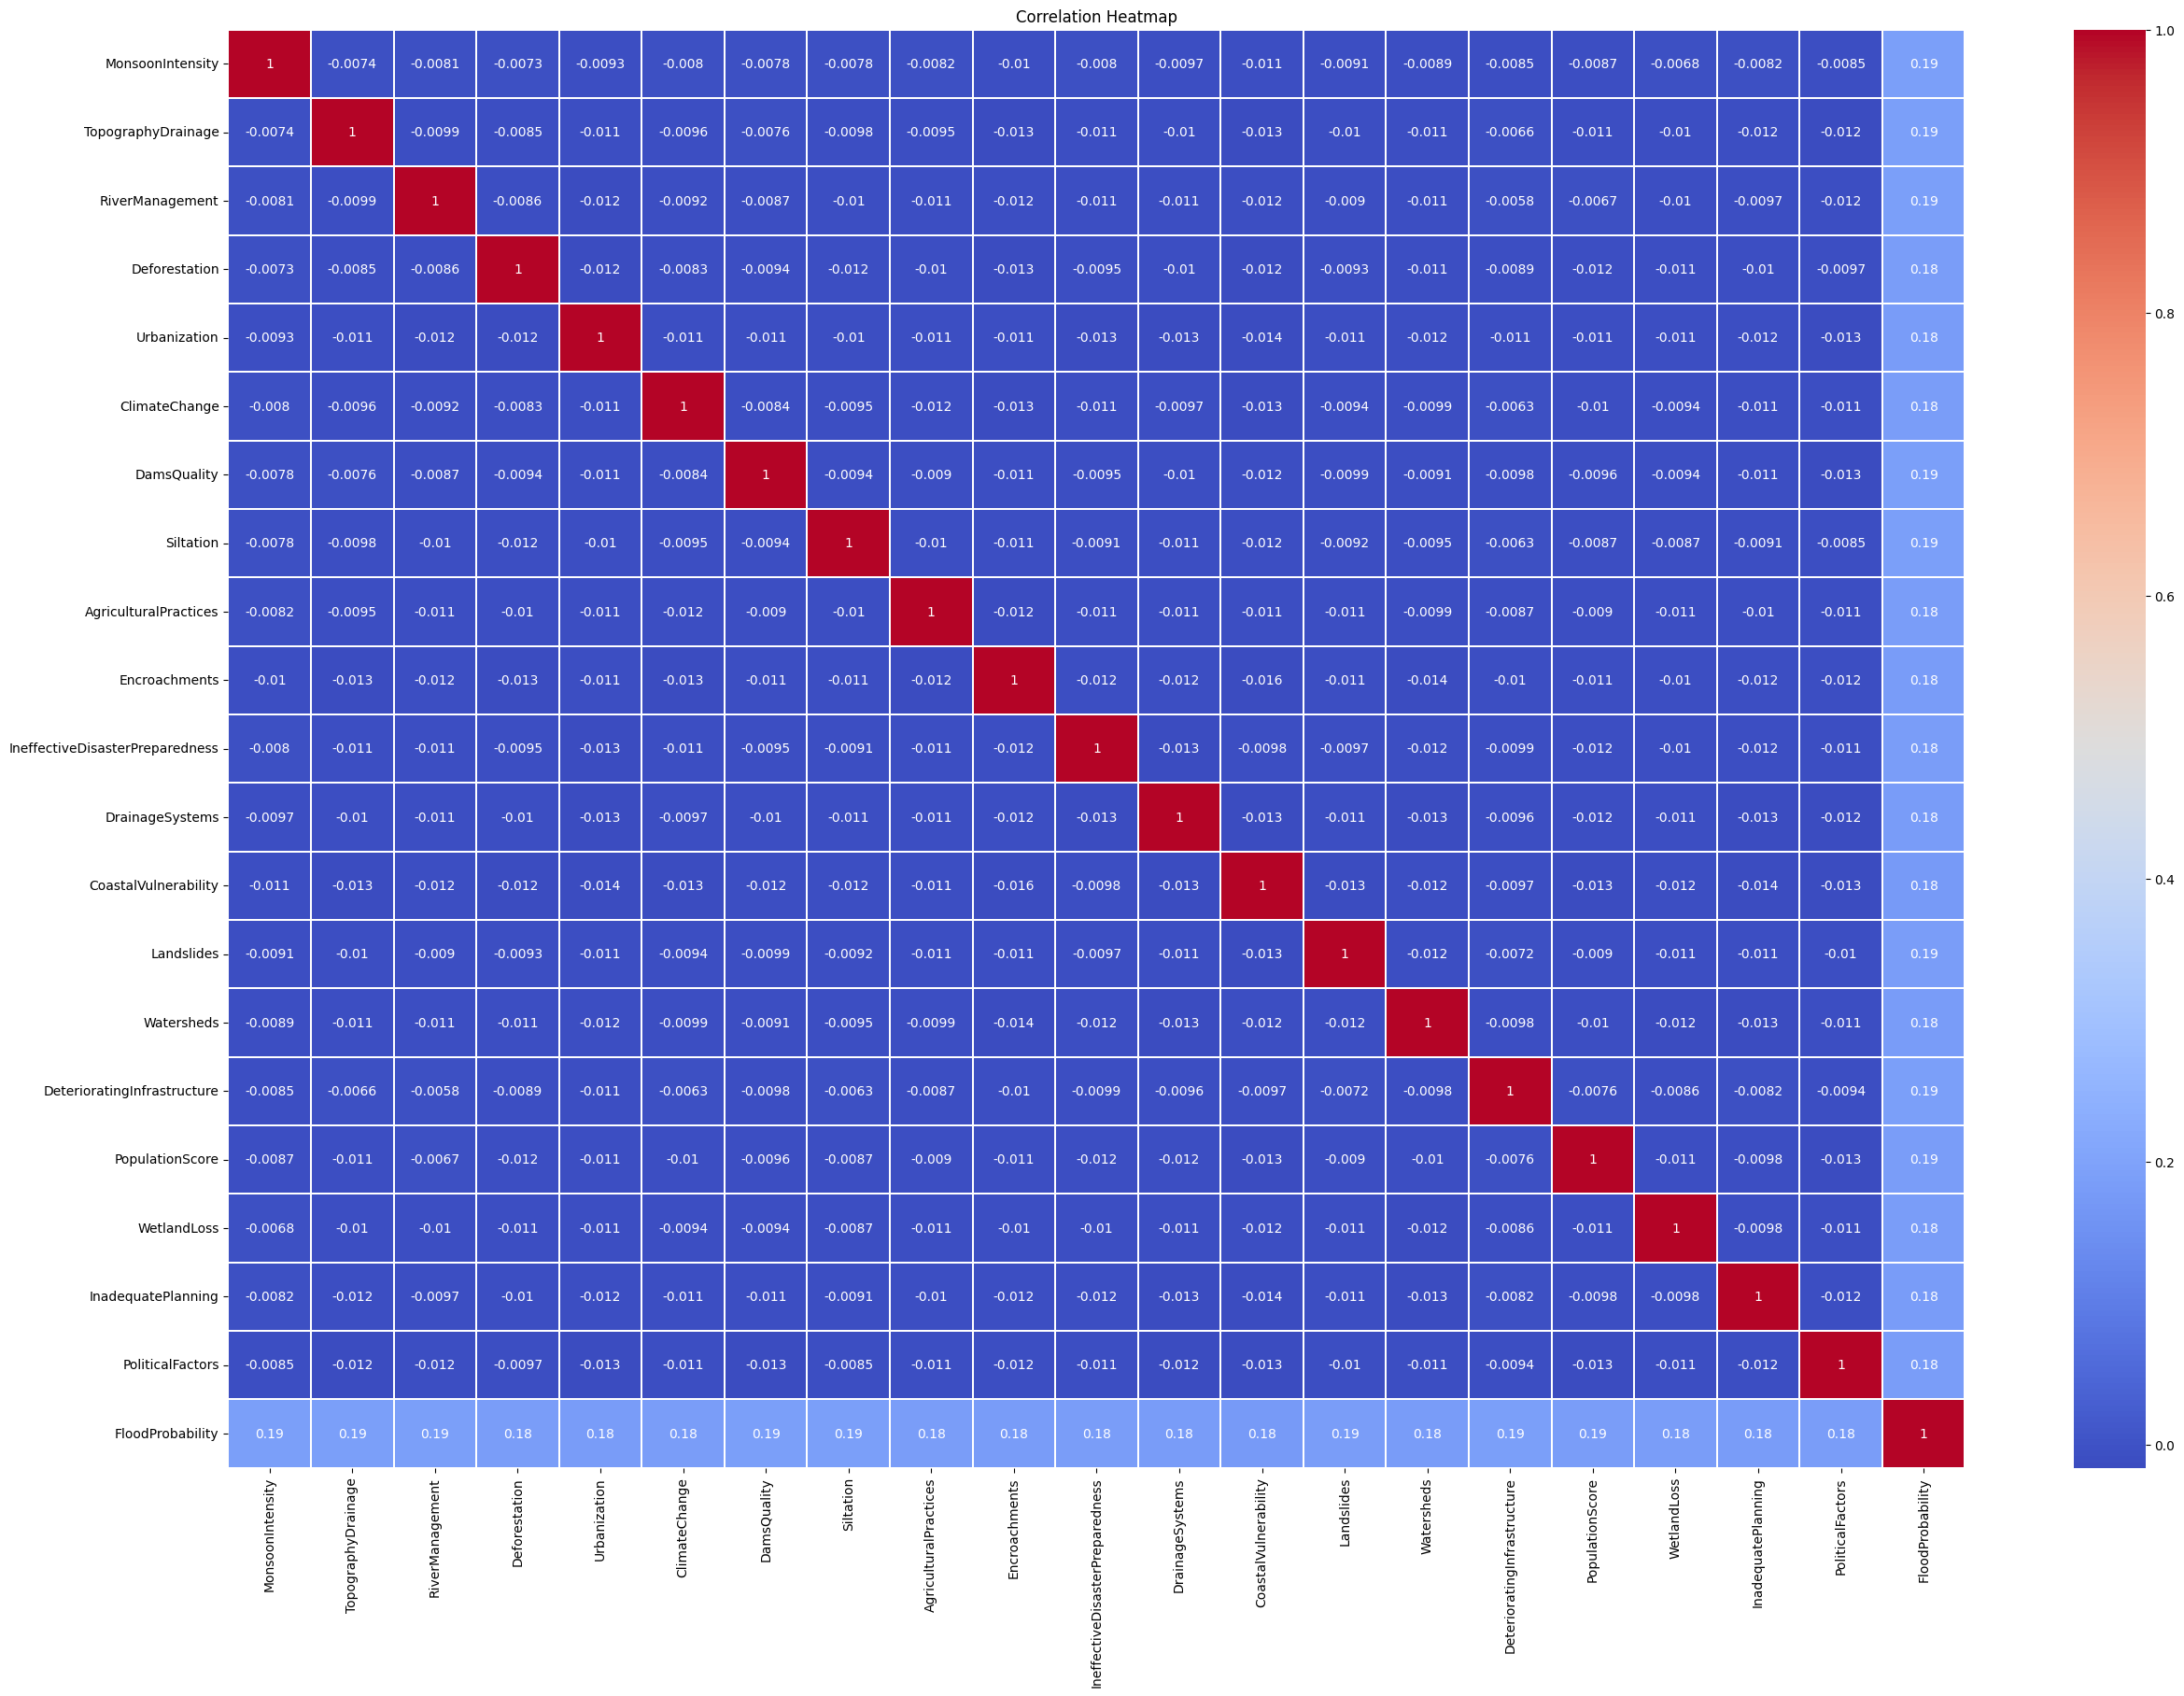

In [ ]:
plt.figure(figsize=(30,20))
corr = df.drop('id',axis=1).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.3)
plt.title('Correlation Heatmap')
plt.show()

##Finding important features


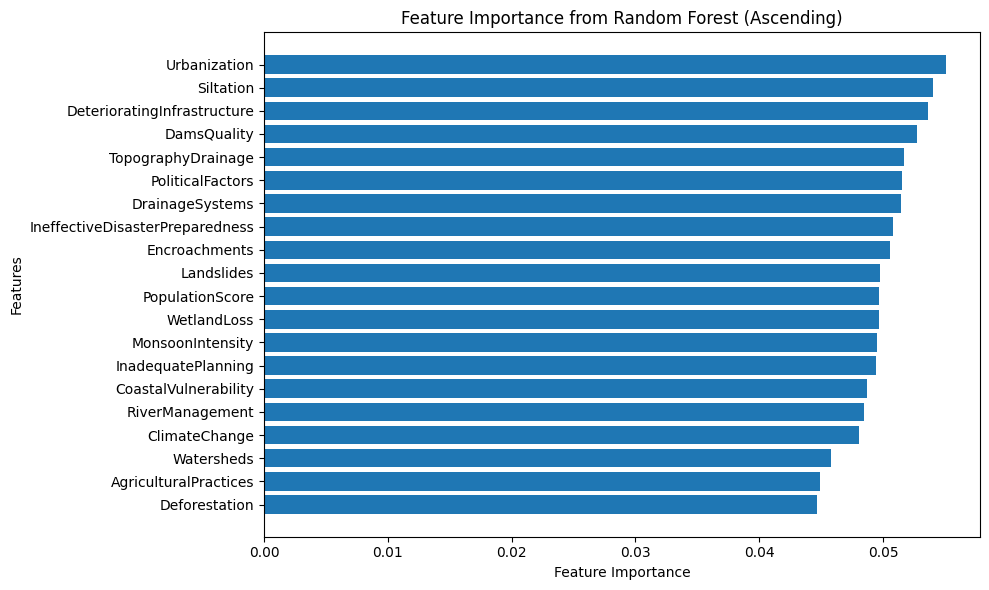

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

#split the data into predictors and target variable
x=df.drop(['id','FloodProbability'],axis=1)
y=df['FloodProbability']

# Create a Random Forest model
model = RandomForestRegressor()

# Fit the model
model.fit(x[:10000], y[:10000])

# Get importance scores
importances = model.feature_importances_
feature_names = x.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance from Random Forest (Ascending)")
plt.tight_layout()
plt.show()

##Plots

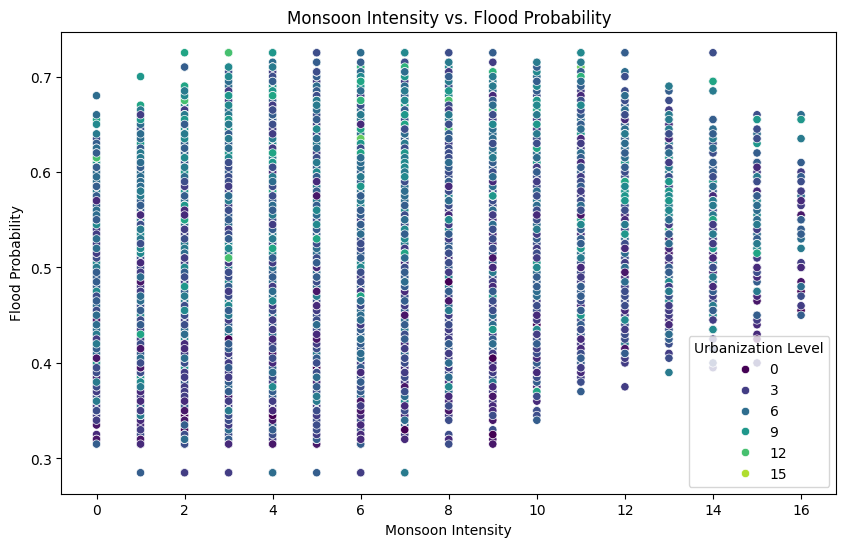

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MonsoonIntensity', y='FloodProbability', hue='Urbanization', palette='viridis')
plt.title('Monsoon Intensity vs. Flood Probability')
plt.xlabel('Monsoon Intensity')
plt.ylabel('Flood Probability')
plt.legend(title='Urbanization Level')
plt.show()

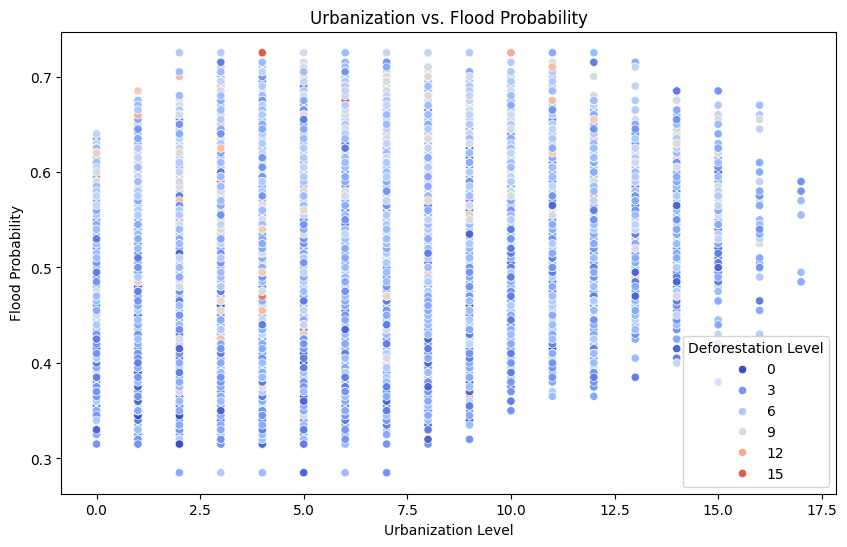

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Urbanization', y='FloodProbability', hue='Deforestation', palette='coolwarm')
plt.title('Urbanization vs. Flood Probability')
plt.xlabel('Urbanization Level')
plt.ylabel('Flood Probability')
plt.legend(title='Deforestation Level')
plt.show()

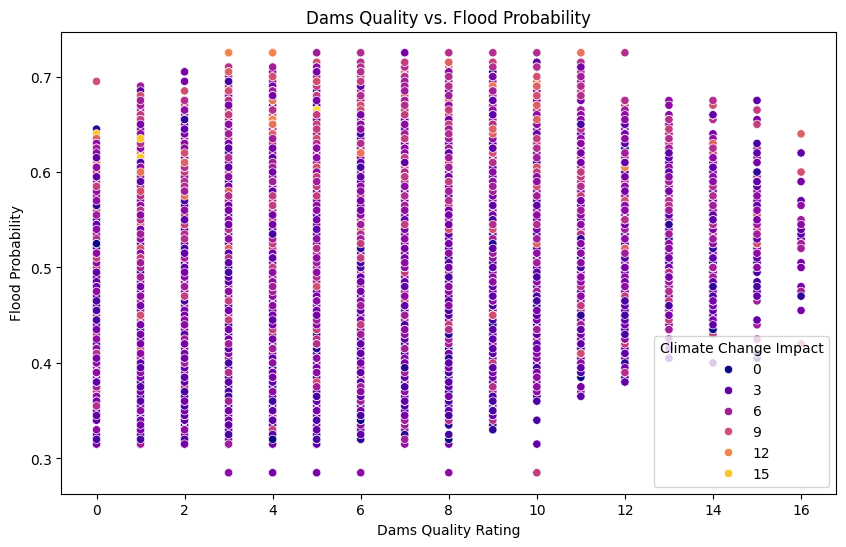

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='DamsQuality', y='FloodProbability', hue='ClimateChange', palette='plasma')
plt.title('Dams Quality vs. Flood Probability')
plt.xlabel('Dams Quality Rating')
plt.ylabel('Flood Probability')
plt.legend(title='Climate Change Impact')
plt.show()

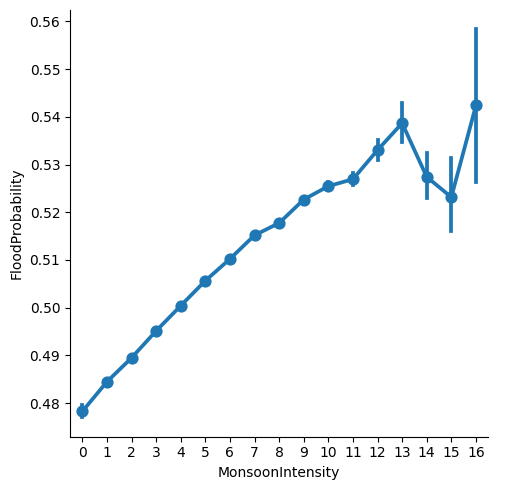

In [ ]:
import seaborn as sns
sns.catplot(x='MonsoonIntensity',y='FloodProbability',data=df, kind='point')

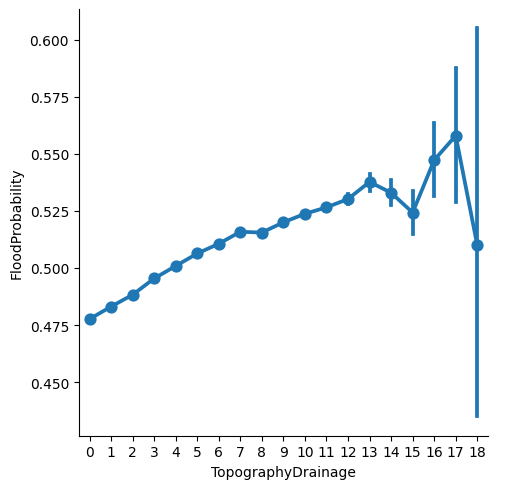

In [ ]:
sns.catplot(x='TopographyDrainage',y='FloodProbability',data=df, kind='point')

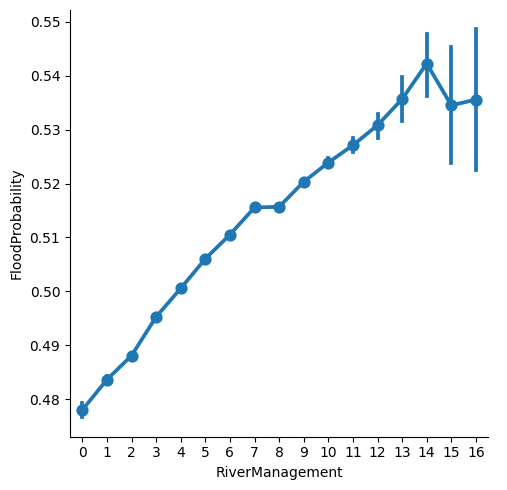

In [ ]:
sns.catplot(x='RiverManagement',y='FloodProbability',data=df, kind='point')

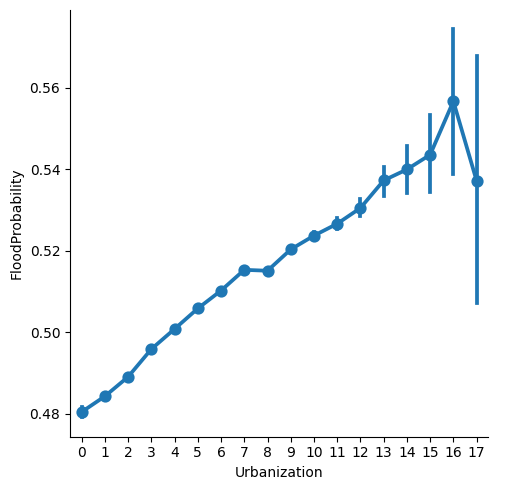

In [ ]:
sns.catplot(x='Urbanization',y='FloodProbability',data=df, kind='point')

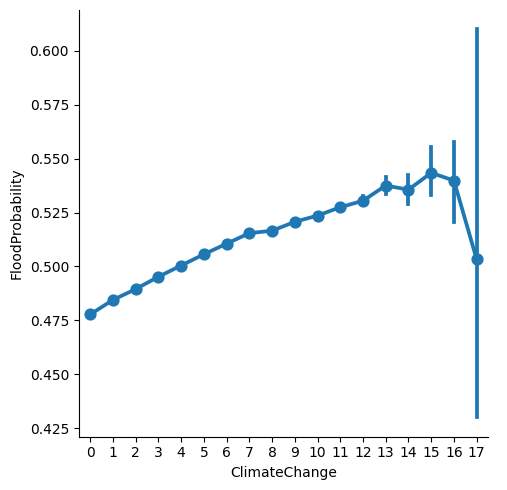

In [ ]:
sns.catplot(x='ClimateChange',y='FloodProbability',data=df, kind='point')

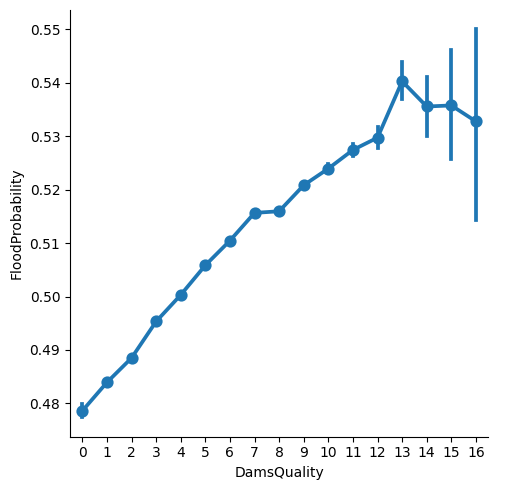

In [ ]:
sns.catplot(x='DamsQuality',y='FloodProbability',data=df, kind='point')

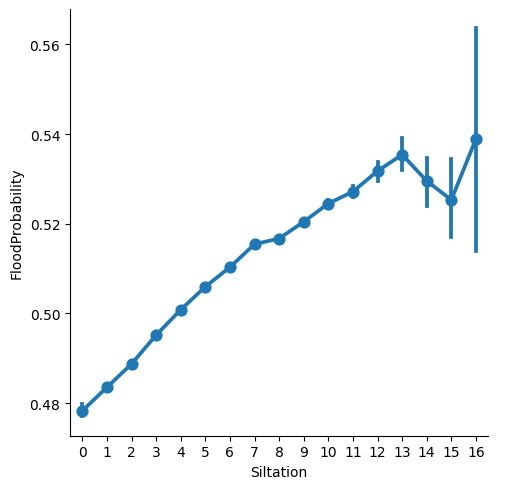

In [ ]:
sns.catplot(x='Siltation',y='FloodProbability',data=df, kind='point')

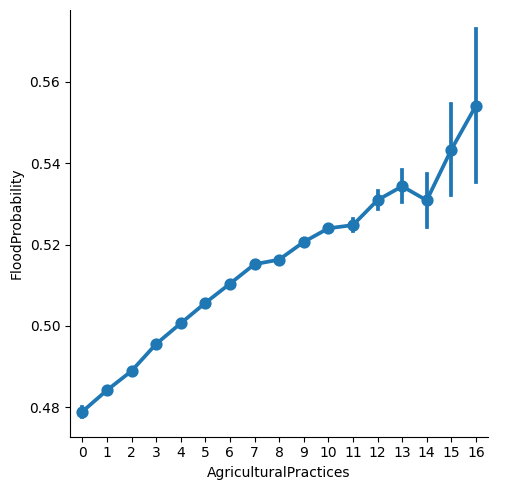

In [ ]:
sns.catplot(x='AgriculturalPractices',y='FloodProbability',data=df, kind='point')

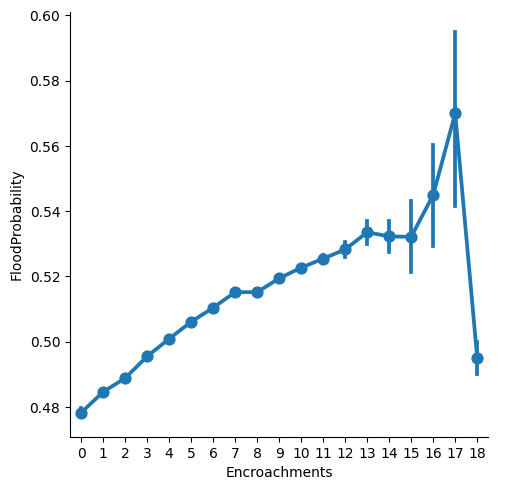

In [ ]:
sns.catplot(x='Encroachments',y='FloodProbability',data=df, kind='point')

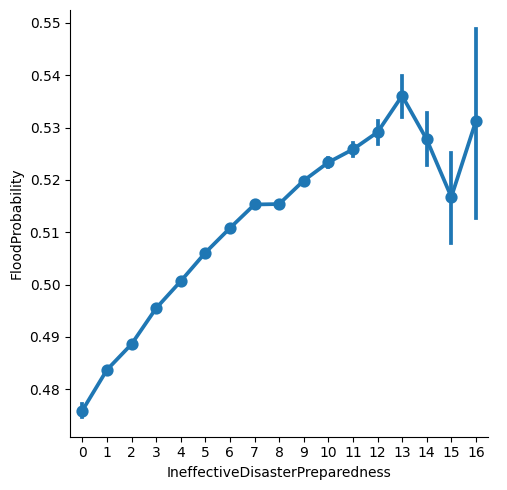

In [ ]:
sns.catplot(x='IneffectiveDisasterPreparedness',y='FloodProbability',data=df, kind='point')

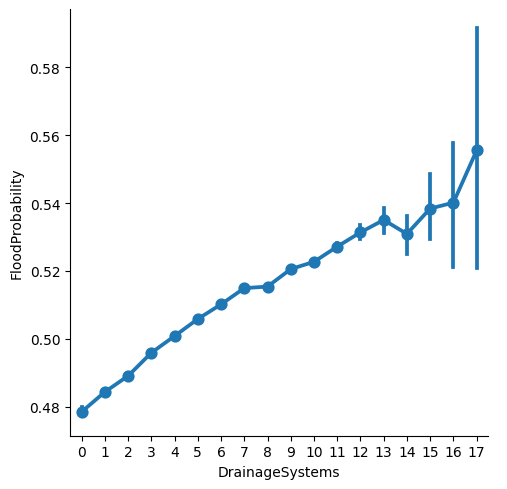

In [ ]:
sns.catplot(x='DrainageSystems',y='FloodProbability',data=df, kind='point')

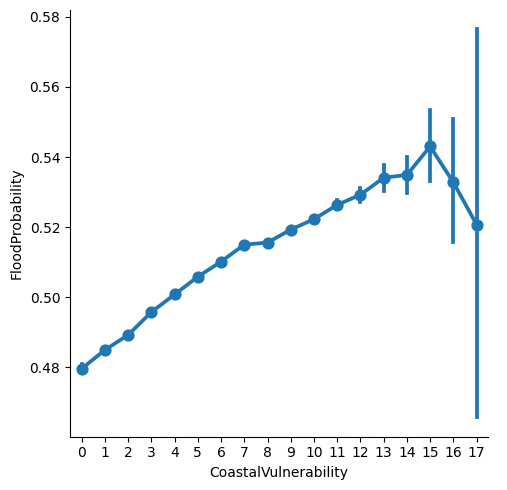

In [ ]:
sns.catplot(x='CoastalVulnerability',y='FloodProbability',data=df, kind='point')

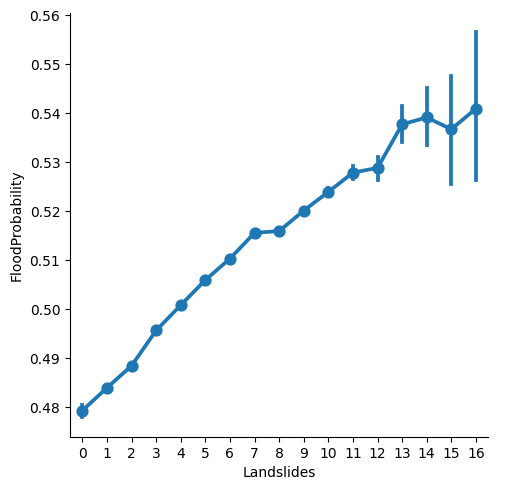

In [ ]:
sns.catplot(x='Landslides',y='FloodProbability',data=df, kind='point')

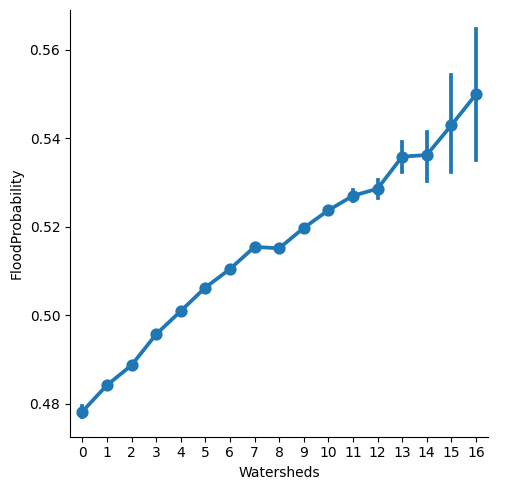

In [ ]:
sns.catplot(x='Watersheds',y='FloodProbability',data=df, kind='point')

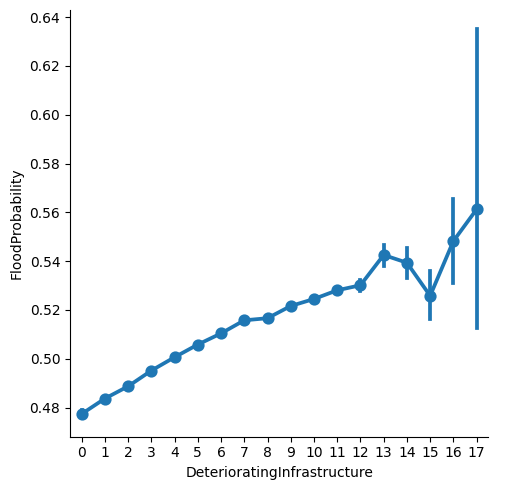

In [ ]:
sns.catplot(x='DeterioratingInfrastructure',y='FloodProbability',data=df, kind='point')

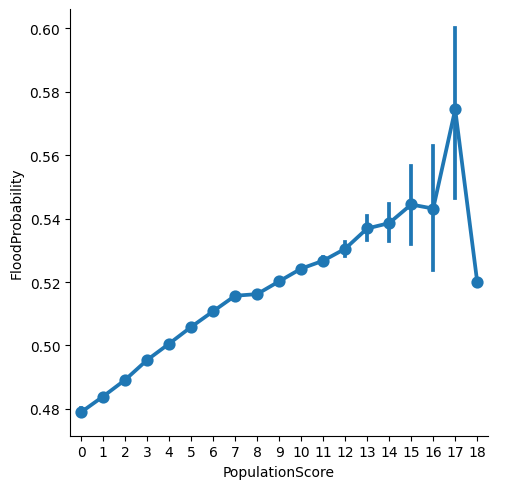

In [ ]:
sns.catplot(x='PopulationScore',y='FloodProbability',data=df, kind='point')

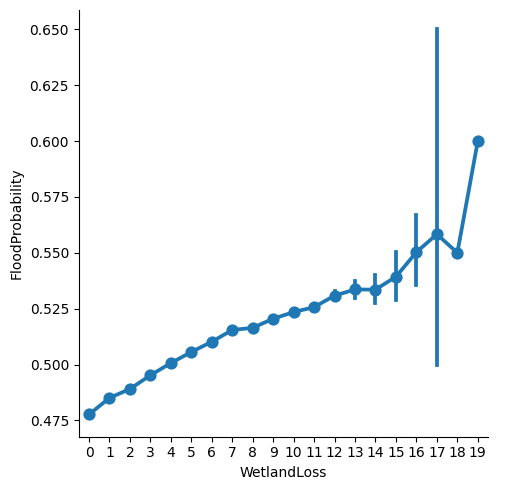

In [ ]:
sns.catplot(x='WetlandLoss',y='FloodProbability',data=df, kind='point')

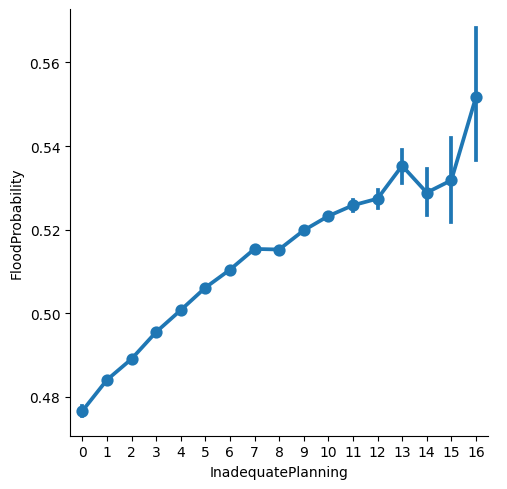

In [ ]:
sns.catplot(x='InadequatePlanning',y='FloodProbability',data=df, kind='point')

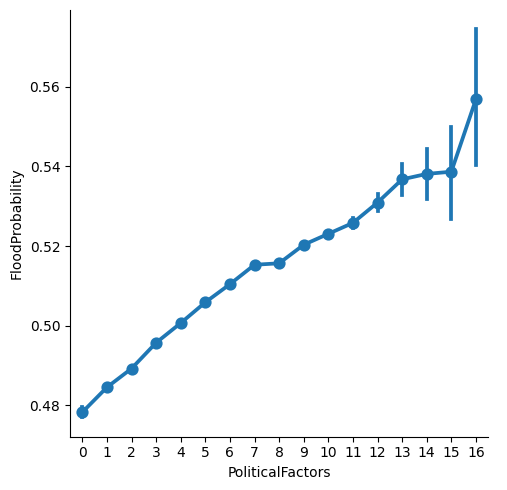

In [ ]:
sns.catplot(x='PoliticalFactors',y='FloodProbability',data=df, kind='point')